# 분류 모델

기계학습의 분류 모델은 주어진 입력 데이터를 미리 정의된 여러 개의 클래스(카테고리) 중 하나로 분류하는 작업을 수행한다.

분류 모델의 주요 목표는 입력 데이터의 특성을 학습하고, 이를 바탕으로 새로운 데이터가 들어왔을 때 해당 데이터를 올바른 클래스에 배정하는 것이다.

분류 모델은 종속 변수가 범주형일 때 주로 사용되며, 이항 분류(두 개의 클래스)와 다항 분류(세 개 이상의 클래스)를 다룰 수 있다.

**분류 알고리즘**

<table>
    <thead>
        <tr>
            <th>알고리즘</th>
            <th>설명</th>
            <th>특징</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>로지스틱 회귀 <code>sklearn.linear_model.LogisticRegression</code></td>
            <td>선형 회귀의 확장판으로, 종속 변수가 범주형일 때 사용됩니다.</td>
            <td>출력 값은 특정 클래스에 속할 확률로 해석됩니다.</td>
        </tr>
        <tr>
            <td>결정 트리 <code>sklearn.tree.DecisionTreeClassifier</code></td>
            <td>데이터의 속성에 따라 분할하여 학습하는 알고리즘으로, 트리 구조를 통해 분류합니다.</td>
            <td>이해하기 쉽고 해석이 용이합니다.</td>
        </tr>
        <tr>
            <td>서포트 벡터 머신 <code>sklearn.svm.SVC</code></td>
            <td>고차원 공간에서 데이터 포인트를 분리하는 초평면을 찾아내는 알고리즘입니다.</td>
            <td>데이터가 선형적으로 구분되지 않을 경우 커널 트릭을 사용합니다.</td>
        </tr>
        <tr>
            <td>k-최근접 이웃 <code>sklearn.neighbors.KNeighborsClassifier</code></td>
            <td>새로운 데이터 포인트가 주어지면 가장 가까운 k개의 이웃 데이터를 참고하여 분류합니다.</td>
            <td>계산 비용이 높고, 데이터의 크기에 민감합니다.</td>
        </tr>
        <tr>
            <td>나이브 베이즈 <code>sklearn.naive_bayes.GaussianNB</code></td>
            <td>베이즈 정리를 기반으로 하며, 모든 특징이 독립적이라는 가정하에 분류를 수행합니다.</td>
            <td>텍스트 분류에 자주 사용됩니다.</td>
        </tr>
        <tr>
            <td>랜덤 포레스트 <code>sklearn.ensemble.RandomForestClassifier</code></td>
            <td>여러 개의 결정 트리를 앙상블하여 예측 성능을 향상시키는 방법입니다.</td>
            <td>과적합을 방지하고 안정적인 예측을 제공합니다.</td>
        </tr>
        <tr>
            <td>그래디언트 부스팅 <code>sklearn.ensemble.GradientBoostingClassifier</code></td>
            <td>여러 개의 약한 학습기(주로 결정 트리)를 순차적으로 학습하여 강한 예측 모델을 만듭니다.</td>
            <td>XGBoost, LightGBM 등이 대표적입니다.</td>
        </tr>
        <tr>
            <td>가우시안 혼합 모델 <code>sklearn.mixture.GaussianMixture</code></td>
            <td>데이터가 여러 개의 가우시안 분포로 구성되어 있다고 가정하고, EM 알고리즘을 사용하여 파라미터를 추정합니다.</td>
            <td>주로 군집화에 사용됩니다.</td>
        </tr>
        <tr>
            <td>신경망 <code>sklearn.neural_network.MLPClassifier</code></td>
            <td>여러 개의 은닉층을 가지는 다층 퍼셉트론(Multilayer Perceptron, MLP) 등의 구조로, 비선형 문제를 해결하는 데 강력합니다.</td>
            <td>딥러닝의 기초가 됩니다.</td>
        </tr>
    </tbody>
</table>


# LogisticRegression
- 회귀와 Logistic함수(sigmoid)를 통해서 분류예측하는 모델
- 이진/다중분류 모두 지원

## 이진분류
양성클래스를 예측하는 모델

1. 양성클래스에 대한 회귀식(회귀계수) 계산
2. 확률값 변환(sigmoid함수)
3. 1 - 양성클래스 확률값을 통해 음성클래스에 대한 확률 계산


### 로지스틱 함수 (Logistic Function) - 시그모이드 함수
**선형 방정식의 출력을 확률로 변환**해준다. 이 함수는 0과 1 사이의 값을 반환하여 분류 문제에서 이진 분류에 적합하다.

**시그모이드 함수 정의**

$
h(z) = \frac{1}{1 + e^{-z}}
$

여기서 $ z $는 입력값으로, 선형 방정식의 결과물이다.

**시그모이드 함수의 특징**
- 출력 값은 항상 0과 1 사이이다.
- $ z \to \infty $ 일 때, $ h(z) \to 1 $
- $ z \to -\infty $ 일 때, $ h(z) \to 0 $

**역할**
- **로지스틱 회귀**에서는 선형 결합을 시그모이드 함수에 넣어 0과 1 사이의 값을 얻고, 이를 확률로 해석한다.
- 이 값을 기준으로, 분류 문제에서 **0.5** 이상이면 클래스 1로, 그 미만이면 클래스 0으로 분류한다.

**정리**
1. 선형회귀 결과값(z) 계산
2. 시그모이드 함수에 z를 넣어 양성에 대한 확률값 계산
3. 0일때 확률도 마저 계산
4. 0.5를 기준으로 이진분류(0, 1) 수행

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

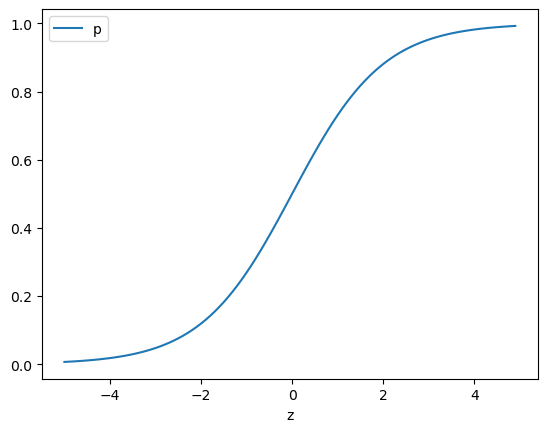

In [11]:
# 시그모이드 함수
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.arange(-5, 5, 0.1)
p = sigmoid(z) # 0 ~ 1사이의 확률값

df = pd.DataFrame({
    'z': z,
    'p': p
})
df.plot(x='z', y='p')
plt.show()


In [12]:
# 생선 이진분류
fish_df = pd.read_csv('data/fish.csv')
fish_df['Species'].value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In [13]:
is_bream_or_smelt = (fish_df['Species'] == 'Bream') | (fish_df['Species'] == 'Smelt')
fish_df = fish_df[is_bream_or_smelt]
fish_df['Species'].value_counts()

Species
Bream    35
Smelt    14
Name: count, dtype: int64

In [14]:
# 데이터 준비
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = fish_df.drop('Species', axis=1).to_numpy()
y = fish_df['Species'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
# 학습/평가
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression()
lr_clf.fit(X_train_scaled, y_train)

print('학습셋 Accuracy:', lr_clf.score(X_train_scaled, y_train))
print('평가셋 Accuracy:', lr_clf.score(X_test_scaled, y_test))


학습셋 Accuracy: 1.0
평가셋 Accuracy: 1.0


In [20]:
# 확률 값 확인
print(lr_clf.classes_)

y_pred = lr_clf.predict(X_test_scaled[:3])
print(y_pred)

y_pred_proba = lr_clf.predict_proba(X_test_scaled[:3])
print(y_pred_proba)

# 학습 된 회귀계수/절편
print("coef:", lr_clf.coef_)
print("intercept:", lr_clf.intercept_)

# 회귀식 결과 값(z) : 양성 클래스에 대한 회귀식
z = lr_clf.decision_function(X_test_scaled[:3])
z = lr_clf.coef_ @ X_test_scaled[:3].T + lr_clf.intercept_  # (1, 5) @ (3, 5).T
print("회귀식 결과 값(z):", z)
print("양성 확률 값:", sigmoid(z))
print("음성 확률 값:", 1 - sigmoid(z))

['Bream' 'Smelt']
['Bream' 'Bream' 'Smelt']
[[0.99096543 0.00903457]
 [0.99432217 0.00567783]
 [0.04998825 0.95001175]]
coef: [[-0.57089591 -0.80002209 -0.83364179 -0.86805125 -0.81749383]]
intercept: [-2.68396424]
회귀식 결과 값(z): [[-4.69762116 -5.16549188  2.94468638]]
양성 확률 값: [[0.00903457 0.00567783 0.95001175]]
음성 확률 값: [[0.99096543 0.99432217 0.04998825]]


## 다중분류

### softmax 함수
**소프트맥스 함수**는 **다중 클래스 분류**를 위한 활성화 함수로, 각 클래스에 대한 확률을 반환한다.

Logistic regression의 softmax 함수는 다중 클래스 분류 문제에서 사용되는 확률적 모델이다. 이 함수는 입력된 각 클래스에 대한 점수를 확률로 변환하여, 전체 클래스 중 하나를 예측할 수 있게 한다.

**Softmax 함수 개념:**
Softmax 함수는 $K$개의 클래스를 가정했을 때, 주어진 입력 데이터에 대해 각 클래스의 확률을 다음과 같이 계산한다:

$$
softmax(z_i) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}
$$

- $z_k$: 각 클래스에 대한 점수(입력 값)
- $e^{z_k}$: 해당 점수에 대해 지수 함수 적용
- $\sum_{j=1}^{K} e^{z_j}$: 모든 클래스 점수에 대해 지수 함수 적용 후의 총합


Softmax 함수는 **여러 개의 값을 확률로 변환**하는 함수다. 이 함수는 각 값을 비교하여 상대적으로 **더 큰 값일수록 더 높은 확률**을 할당하는 방식으로 작동한다.

**설명**
1. **입력 값들**: Softmax 함수는 여러 숫자를 입력으로 받는다. 예를 들어, `[2.0, 1.0, 0.1]`이라는 세 개의 값을 받았다고 하자.
2. **지수 함수 적용**: 각 숫자에 대해 지수 함수 $e^x$를 적용한다. 이는 숫자를 양수로 변환하고, 값이 클수록 더 큰 값으로 변환한다.
    - $e^{2.0} \approx 7.39$
    - $e^{1.0} \approx 2.72$
    - $e^{0.1} \approx 1.11$

3. **모든 값을 더하기**: 이렇게 변환된 값들을 모두 더한다. 이 값이 나중에 분모가 된다.
    - $7.39 + 2.72 + 1.11 = 11.22$

4. **각 값을 나누기**: 이제 각 값을 이 총합으로 나눠서 **각 값의 비율을 구한다**. 이 값들이 각 값에 대응하는 확률이다.
    - 첫 번째 값: $\frac{7.39}{11.22} \approx 0.659$ → 약 65.9% 확률
    - 두 번째 값: $\frac{2.72}{11.22} \approx 0.242$ → 약 24.2% 확률
    - 세 번째 값: $\frac{1.11}{11.22} \approx 0.099$ → 약 9.9% 확률

**아주 쉽게 정리하자면**
1. 숫자를 e의 지수로 적용해서 아주 크게 만들고(차이가 도드러지도록),
2. 그 숫자들의 총합을 구한 후,
3. 각 숫자를 총합으로 나누어서 확률로 만든다.

입력 x
→ 선형결합 (z = Wx + b)
→ softmax(z)
→ 확률 p
→ argmax(p)
→ 최종 클래스

In [21]:
def softmax(z):
    exp_z = np.exp(z - np.max(z)) # 지수식 안정화
    return exp_z / exp_z.sum(axis=1, keepdims=True) # keepdims=True 연산후 차원유지

z = np.array([[2, 1, 0.1], [1, 3, 2.5]])
p = softmax(z)
print(p)
pred = np.argmax(p, axis=1)
print(pred)

[[0.65900114 0.24243297 0.09856589]
 [0.07769558 0.57409699 0.34820743]]
[0 1]


In [22]:
# 데이터 준비 (다중분류)
fish_df = pd.read_csv('data/fish.csv')

X = fish_df.drop('Species', axis=1).to_numpy()
y = fish_df['Species'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# 모델 학습/평가
lr_clf = LogisticRegression()
lr_clf.fit(X_train_scaled, y_train)

print('학습셋: ', lr_clf.score(X_train_scaled, y_train))
print('평가셋: ', lr_clf.score(X_test_scaled, y_test))

학습셋:  0.8188976377952756
평가셋:  0.8125


In [25]:
# 확률 값 확인
print(lr_clf.classes_)

y_pred = lr_clf.predict(X_test_scaled[:3])
print(y_pred)

y_pred_proba = lr_clf.predict_proba(X_test_scaled[:3])
print(y_pred_proba)

# 학습 된 회귀계수/절편
print("coef:", lr_clf.coef_)
print("intercept:", lr_clf.intercept_)

# 회귀식 결과 값(z) : 각 클래스에 대한 회귀식
z = lr_clf.decision_function(X_test_scaled[:3])
print("회귀식 결과 값(z):", z)
print("클래스별 확률 값:", softmax(z))
print("클래스 예측 값:", np.argmax(softmax(z), axis=1))

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
['Bream' 'Perch' 'Smelt']
[[9.58109313e-01 5.58762858e-03 8.82637677e-03 1.73022352e-03
  1.89120066e-03 1.06585653e-07 2.38551507e-02]
 [2.65281500e-02 6.67860863e-02 5.58123698e-01 2.08252578e-02
  2.77528039e-01 5.01290083e-03 4.51958680e-02]
 [1.69316851e-04 4.56231322e-02 1.36483382e-01 1.72290732e-03
  7.76098530e-02 7.36301262e-01 2.09014731e-03]]
coef: [[-0.14465787 -0.13548296  0.68288893  2.96260478 -0.29419159]
 [-0.38885353 -0.77491848 -0.78308841  1.95731656 -0.78136184]
 [ 1.11689927  0.39450341 -1.36444504 -1.87713167  1.8899914 ]
 [-0.0771949   1.77632726  1.73994138 -1.24453498 -0.7461826 ]
 [-0.84627642 -0.46414948  0.42225457 -0.46306473  0.66305214]
 [-0.36176453 -0.77117752 -0.7636638  -1.35093587 -1.56419215]
 [ 0.70184798 -0.02510224  0.06611236  0.01574591  0.83288464]]
intercept: [ 0.49837482 -0.08605615  2.27031347 -0.06926445  1.04341559 -4.06768339
  0.41090011]
회귀식 결과 값(z): [[  6.0115101    0.867